In [348]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [403]:
df = pd.read_excel("C:\\Users\\nabhe\\Downloads\\Loan_Modelling.xlsx")
df_original = df.copy()

# Understanding dataset

In [404]:
df.head()

,ID,Age,Experience,Income,ZIPCode,Family,CCAvg,Education,Mortgage,Personal_Loan,Securities_Account,CD_Account,Online,CreditCard
0,1,25,1,49,91107,4,1.6,1,0,0,1,0,0,0
1,2,45,19,34,90089,3,1.5,1,0,0,1,0,0,0
2,3,39,15,11,94720,1,1.0,1,0,0,0,0,0,0
3,4,35,9,100,94112,1,2.7,2,0,0,0,0,0,0
4,5,35,8,45,91330,4,1.0,2,0,0,0,0,0,1


In [356]:
df.shape

(5000, 14)

In [293]:
df['ZIPCode'].count()

5000

#### Since ZipCode have all unique values and ID doesn't give any value to model, we can drop them from the dataframe.

In [405]:
# Dopping ID and ZIPCode
df.drop(['ID', 'ZIPCode'], axis=1, inplace=True)
df.shape

(5000, 12)

In [295]:
df.duplicated().sum()

13

In [296]:
df[df.duplicated()]

,Age,Experience,Income,Family,CCAvg,Education,Mortgage,Personal_Loan,Securities_Account,CD_Account,Online,CreditCard
799,29,3,39,4,2.10,3,0,0,0,0,1,0
1026,28,4,43,3,0.10,2,0,0,0,0,1,0
1526,36,10,80,4,2.20,2,0,0,0,0,1,0
2031,60,35,80,3,0.50,1,0,0,0,0,1,0
2806,53,27,59,2,0.80,3,0,0,0,0,1,0
3050,50,25,58,1,1.30,2,0,0,0,0,1,0
3453,29,3,31,4,0.30,2,0,0,0,0,1,0
3694,38,8,21,1,0.67,3,0,0,0,0,1,0
4058,39,15,65,1,1.50,3,0,0,0,0,0,0
4482,40,14,28,2,0.80,3,0,0,0,0,0,0


#### These duplicated values doesn't look real duplicate. Education, Mortgage, Personal loan, securities account, cd account, online and credit card values could be similar. No need to get rid of them.

In [297]:
df.isna().sum()

Age                   0
Experience            0
Income                0
Family                0
CCAvg                 0
Education             0
Mortgage              0
Personal_Loan         0
Securities_Account    0
CD_Account            0
Online                0
CreditCard            0
dtype: int64

#### No null values.

In [298]:
# Basic statistics
df.describe().round(4)

,Age,Experience,Income,Family,CCAvg,Education,Mortgage,Personal_Loan,Securities_Account,CD_Account,Online,CreditCard
count,5000.0000,5000.0000,5000.0000,5000.0000,5000.0000,5000.0000,5000.0000,5000.0000,5000.0000,5000.0000,5000.0000,5000.0000
mean,45.3384,20.1046,73.7742,2.3964,1.9379,1.8810,56.4988,0.0960,0.1044,0.0604,0.5968,0.2940
std,11.4632,11.4680,46.0337,1.1477,1.7477,0.8399,101.7138,0.2946,0.3058,0.2383,0.4906,0.4556
min,23.0000,-3.0000,8.0000,1.0000,0.0000,1.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000
25%,35.0000,10.0000,39.0000,1.0000,0.7000,1.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000
50%,45.0000,20.0000,64.0000,2.0000,1.5000,2.0000,0.0000,0.0000,0.0000,0.0000,1.0000,0.0000
75%,55.0000,30.0000,98.0000,3.0000,2.5000,3.0000,101.0000,0.0000,0.0000,0.0000,1.0000,1.0000
max,67.0000,43.0000,224.0000,4.0000,10.0000,3.0000,635.0000,1.0000,1.0000,1.0000,1.0000,1.0000


#### min value of Experience is -3 which can't be true. 

In [299]:
# Checking negative values
print('No. of -ve values:', (df['Experience'] < 0).sum())
df[df['Experience'] < 0].head()

No. of -ve values: 52


,Age,Experience,Income,Family,CCAvg,Education,Mortgage,Personal_Loan,Securities_Account,CD_Account,Online,CreditCard
89,25,-1,113,4,2.30,3,0,0,0,0,0,1
226,24,-1,39,2,1.70,2,0,0,0,0,0,0
315,24,-2,51,3,0.30,3,0,0,0,0,1,0
451,28,-2,48,2,1.75,3,89,0,0,0,1,0
524,24,-1,75,4,0.20,1,0,0,0,0,1,0


# Univariate Analysis

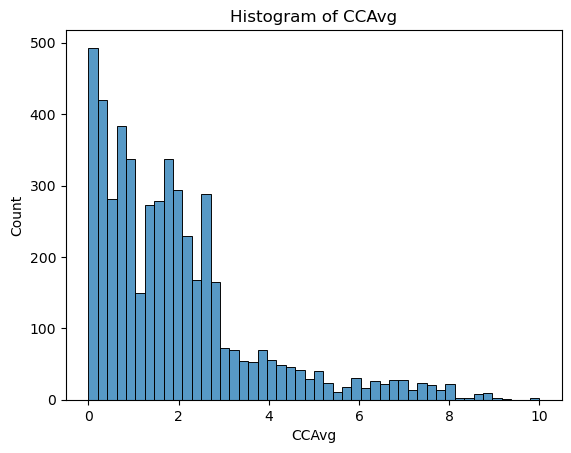

In [301]:
# Distribution of target variable
sns.histplot(data=df, x='CCAvg')
plt.title('Histogram of CCAvg')
plt.show()

#### Rightly skewed data. Most customers spend upto 3,000 dollars.

In [302]:
df.columns

Index(['Age', 'Experience', 'Income', 'Family', 'CCAvg', 'Education',
       'Mortgage', 'Personal_Loan', 'Securities_Account', 'CD_Account',
       'Online', 'CreditCard'],
      dtype='object')

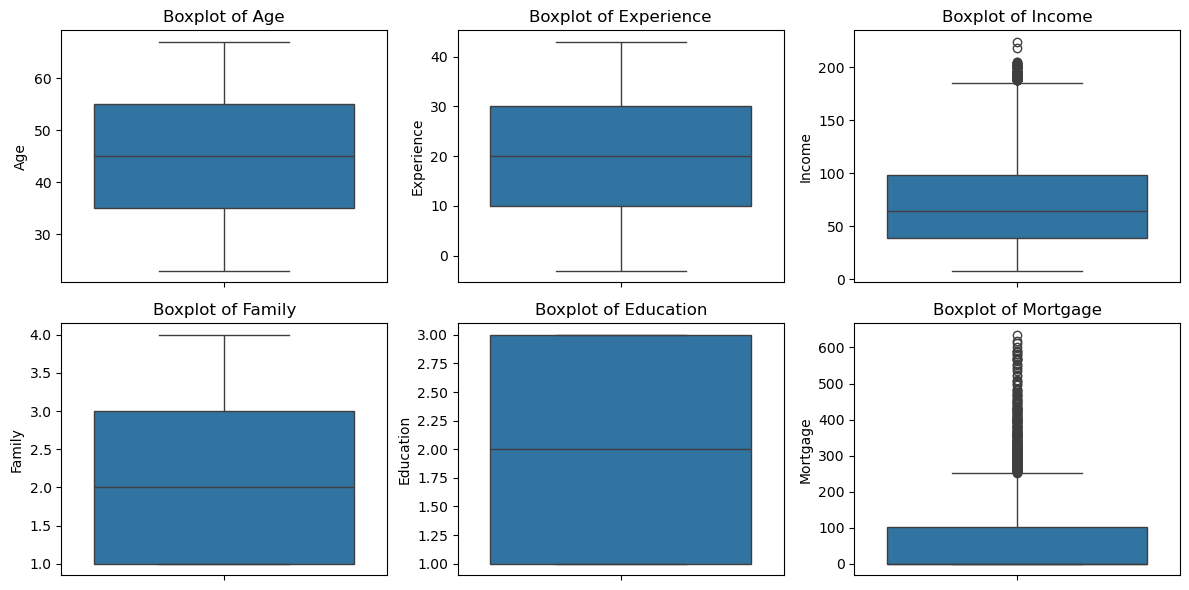

In [303]:
# Checking boxplots
real_num_var = ['Age', 'Experience', 'Income', 'Family', 'Education', 'Mortgage']
plt.figure(figsize=(12,6))
for idx, rnv in enumerate(real_num_var, 1):
    plt.subplot(2,3,idx)
    sns.boxplot(data=df, y=rnv)
    plt.title(f'Boxplot of {rnv}')
plt.tight_layout()
plt.show()

#### Outliers of Income and Mortgage are real and valid. Log transformation looks appropriate since both are rightly skewed.

# Bivariate Analysis

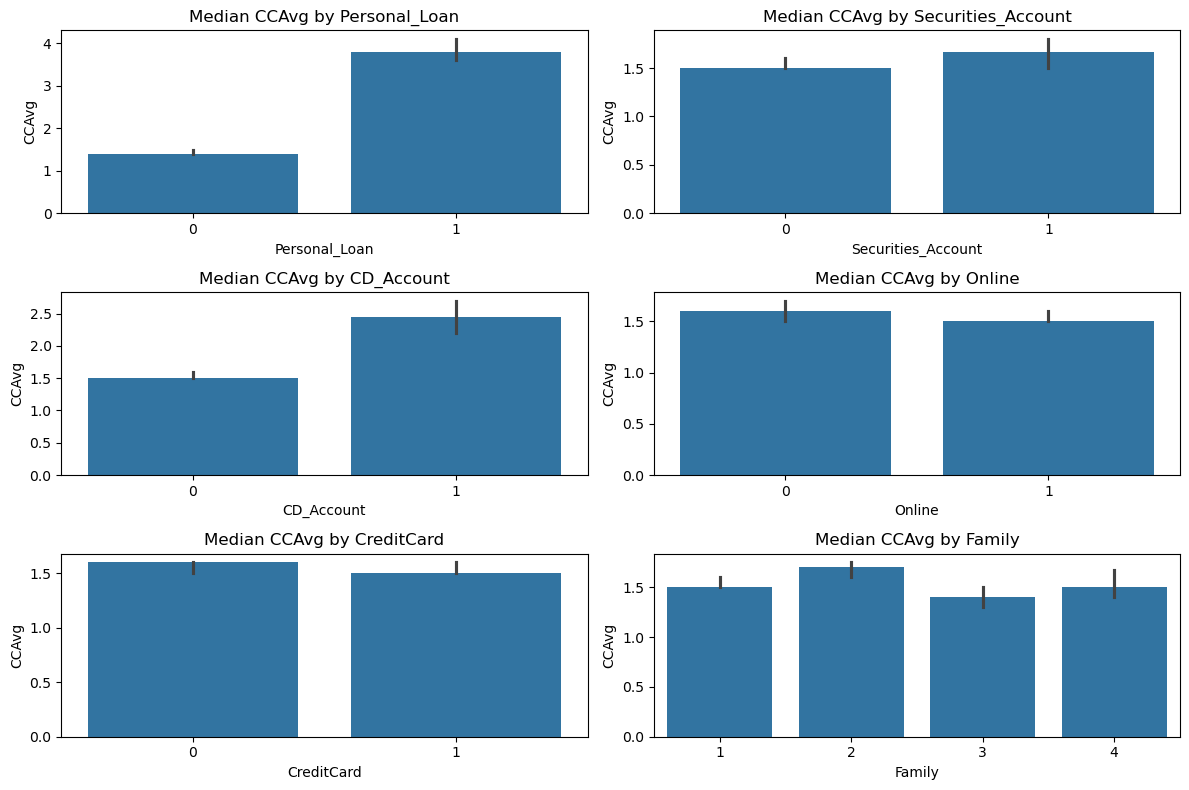

In [304]:
cat_num_var = ['Personal_Loan', 'Securities_Account', 'CD_Account', 'Online', 'CreditCard', 'Family']
plt.figure(figsize=(12,8))
for idx, cnv in enumerate(cat_num_var, 1):
    plt.subplot(3,2,idx)
    sns.barplot(data=df, x=cnv, y='CCAvg', estimator=np.median)
    plt.title(f'Median CCAvg by {cnv}')

plt.tight_layout()
plt.show()

#### The customers who have taken the Personal loan have the most Credit card spending habit in average close to 4,000 per month. 
#### Customers having Certificate of deposit (CD) account are second with the average close to 2,500 per month.

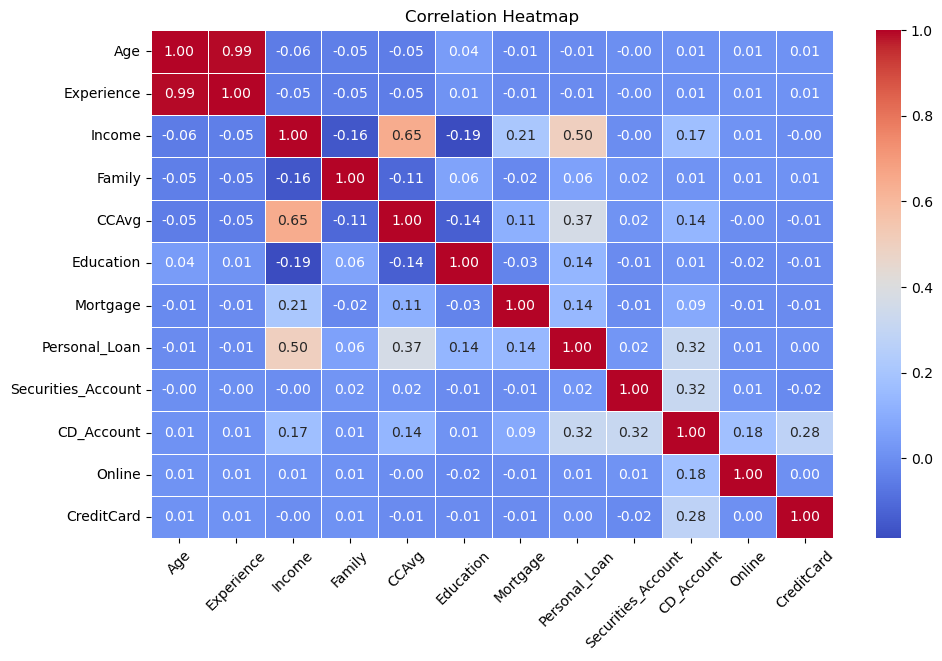

In [305]:
plt.figure(figsize=(11,6.6))
corr_matrix = df.corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Correlation Heatmap')
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.show()

#### Age and Experience almost have perfect correlation with 0.99. Better to remove one of them to avoid having multicollinearity problem.
#### Next important correlation here is between Income and CCAvg with 0.65. 
#### There is moderate +ve correlation between Income and Personal loan with 0.50.

In [406]:
# Dropping Experience variable 
df.drop('Experience', axis=1, inplace= True)  
df.head(1)

,Age,Income,Family,CCAvg,Education,Mortgage,Personal_Loan,Securities_Account,CD_Account,Online,CreditCard
0,25,49,4,1.6,1,0,0,1,0,0,0


In [307]:
df.groupby(['Personal_Loan', 'CD_Account'])[['CCAvg', 'Income']].median().reset_index()

,Personal_Loan,CD_Account,CCAvg,Income
0,0,0,1.4,59.0
1,0,1,1.6,59.5
2,1,0,3.7,141.0
3,1,1,4.1,154.0


#### Higher av. Income taken Personal loan and have the higher av. spendings on Credit card.

In [407]:
# Getting rid of Personal loan since we are predicting it later to avoid data leakage.
df.drop('Personal_Loan', axis=1) 
df.head(1)

,Age,Income,Family,CCAvg,Education,Mortgage,Personal_Loan,Securities_Account,CD_Account,Online,CreditCard
0,25,49,4,1.6,1,0,0,1,0,0,0


In [408]:
# Log transformation
df['Income_log'] = np.log1p(df['Income'])
df['Mortgage_log'] = np.log1p(df['Mortgage'])
df['CCAvg_log'] = np.log1p(df['CCAvg'])

In [409]:
# One_hot encoding Education variable
df = pd.get_dummies(df, columns=['Education'], prefix='Edu', drop_first=True, dtype=int)
df.head(1)

,Age,Income,Family,CCAvg,Mortgage,Personal_Loan,Securities_Account,CD_Account,Online,CreditCard,Income_log,Mortgage_log,CCAvg_log,Edu_2,Edu_3
0,25,49,4,1.6,0,0,1,0,0,0,3.912023,0.0,0.955511,0,0


# 1. Regression

In [410]:
# Inputs for the model
X = df.drop(['Income', 'Mortgage', 'CCAvg', 'CCAvg_log'], axis=1) 
y= df['CCAvg_log']

In [411]:
X.head(1)

,Age,Family,Personal_Loan,Securities_Account,CD_Account,Online,CreditCard,Income_log,Mortgage_log,Edu_2,Edu_3
0,25,4,0,1,0,0,0,3.912023,0.0,0,0


In [412]:
y.head(1)

0    0.955511
Name: CCAvg_log, dtype: float64

In [413]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

In [414]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train) 
X_test_scaled = scaler.transform(X_test) 

# Linear Regression

In [415]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train_scaled, y_train)

LinearRegression()

In [416]:
# Predictions
y_train_pred = model.predict(X_train_scaled)
y_test_pred = model.predict(X_test_scaled)

In [386]:
from sklearn.metrics import r2_score, mean_squared_error

print("Train R2:", r2_score(y_train, y_train_pred))
print("Test R2:", r2_score(y_test, y_test_pred))

print("Train RMSE:", np.sqrt(mean_squared_error(y_train, y_train_pred)))
print("Test RMSE:", np.sqrt(mean_squared_error(y_test, y_test_pred)))

Train R2: 0.3572720169810234
Test R2: 0.3895734460666367
Train RMSE: 0.42811328552532146
Test RMSE: 0.41515418459253106


In [387]:
# Train set
# Convert log values back to original scale
y_train_original = np.expm1(y_train)
y_train_pred_original = np.expm1(y_train_pred)

# Calculate RMSE on original scale
train_rmse = np.sqrt(mean_squared_error(y_train_original, y_train_pred_original))

# Test set
# Convert log values back to original scale
y_test_original = np.expm1(y_test)
y_test_pred_original = np.expm1(y_test_pred)

# Calculate RMSE on original scale
test_rmse = np.sqrt(mean_squared_error(y_test_original, y_test_pred_original))

print("Train RMSE (original scale):", train_rmse)
print("Test RMSE (original scale):", test_rmse)

Train RMSE (original scale): 1.4062961121606177
Test RMSE (original scale): 1.3865865811416898


# Random Forest 

In [388]:
df.head(1)

,Age,Income,Family,CCAvg,Mortgage,Personal_Loan,Securities_Account,CD_Account,Online,CreditCard,Income_log,Mortgage_log,CCAvg_log,Edu_2,Edu_3
0,25,49,4,1.6,0,0,1,0,0,0,3.912023,0.0,0.955511,0,0


#### Since Tree models don't need scaling and log transformation, I'm taking the original features

In [389]:
r_df = df.drop(['Income_log', 'Mortgage_log', 'CCAvg_log'], axis=1)
r_df.head(1)

,Age,Income,Family,CCAvg,Mortgage,Personal_Loan,Securities_Account,CD_Account,Online,CreditCard,Edu_2,Edu_3
0,25,49,4,1.6,0,0,1,0,0,0,0,0


In [390]:
r_X = r_df.drop('CCAvg', axis=1)
r_y = r_df['CCAvg']

In [391]:
X_train, X_test, y_train, y_test = train_test_split(r_X, r_y, test_size=0.3, random_state=42)

In [392]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(n_estimators=200, random_state=42)
rf.fit(X_train, y_train)

# Predictions
rf_train_pred = rf.predict(X_train)
rf_test_pred = rf.predict(X_test)

# Metrics
rf_train_r2 = r2_score(y_train, rf_train_pred)
rf_test_r2 = r2_score(y_test, rf_test_pred)

rf_train_rmse = np.sqrt(mean_squared_error(y_train, rf_train_pred))
rf_test_rmse = np.sqrt(mean_squared_error(y_test, rf_test_pred))

print("Random Forest Train R2:", rf_train_r2)
print("Random Forest Test R2:", rf_test_r2)
print("Random Forest Train RMSE:", rf_train_rmse)
print("Random Forest Test RMSE:", rf_test_rmse)

Random Forest Train R2: 0.9241856899052971
Random Forest Test R2: 0.44467420846184846
Random Forest Train RMSE: 0.4816288121201879
Random Forest Test RMSE: 1.299237174025462


### Tuning

In [393]:
from sklearn.model_selection import GridSearchCV

rf = RandomForestRegressor(random_state=42)

param_grid = {
    "n_estimators": [200, 400],
    "max_depth": [None, 10, 20],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4],
    "max_features": ["sqrt", "log2"]
}

grid = GridSearchCV(
    rf,
    param_grid,
    cv=5,
    scoring="neg_root_mean_squared_error",
    n_jobs=-1,
    verbose=1
)

grid.fit(X_train, y_train)

best_rf = grid.best_estimator_
print("Best Params:", grid.best_params_)
print("Best CV RMSE:", -grid.best_score_)

Fitting 5 folds for each of 108 candidates, totalling 540 fits
Best Params: {'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': 4, 'min_samples_split': 10, 'n_estimators': 200}
Best CV RMSE: 1.2954825937725893


In [278]:
# Best model from tuning
best_rf = RandomForestRegressor(
    n_estimators=400,
    max_depth=20,
    max_features='sqrt',
    min_samples_leaf=4,
    min_samples_split=2,
    random_state=42
)

# Fit on training data
best_rf.fit(X_train, y_train)

# Predictions
rf_train_pred = best_rf.predict(X_train)
rf_test_pred  = best_rf.predict(X_test)

# Metrics
rf_train_r2 = r2_score(y_train, rf_train_pred)
rf_test_r2  = r2_score(y_test, rf_test_pred)

rf_train_rmse = np.sqrt(mean_squared_error(y_train, rf_train_pred))
rf_test_rmse  = np.sqrt(mean_squared_error(y_test, rf_test_pred))

print("Random Forest Train R2:", rf_train_r2)
print("Random Forest Test R2:", rf_test_r2)
print("Random Forest Train RMSE:", rf_train_rmse)
print("Random Forest Test RMSE:", rf_test_rmse)

Random Forest Train R2: 0.6532858982805874
Random Forest Test R2: 0.4704935350734176
Random Forest Train RMSE: 1.0299653602688805
Random Forest Test RMSE: 1.268674321064314


# XGBoost

In [417]:
!pip install xgboost

In [418]:
from xgboost import XGBRegressor

xgb = XGBRegressor(
    n_estimators=200,
    learning_rate=0.1,
    max_depth=4,
    random_state=42
)

xgb.fit(X_train, y_train)  # Using same input as Random forest model

# Predictions
xgb_train_pred = xgb.predict(X_train)
xgb_test_pred = xgb.predict(X_test)

# Metrics
xgb_train_r2 = r2_score(y_train, xgb_train_pred)
xgb_test_r2 = r2_score(y_test, xgb_test_pred)

xgb_train_rmse = np.sqrt(mean_squared_error(y_train, xgb_train_pred))
xgb_test_rmse = np.sqrt(mean_squared_error(y_test, xgb_test_pred))

print("XGBoost Train R2:", xgb_train_r2)
print("XGBoost Test R2:", xgb_test_r2)
print("XGBoost Train RMSE:", xgb_train_rmse)
print("XGBoost Test RMSE:", xgb_test_rmse)

XGBoost Train R2: 0.586527946654329
XGBoost Test R2: 0.3925093914217719
XGBoost Train RMSE: 0.34337461185696166
XGBoost Test RMSE: 0.41415460559704326


### Tuning

In [419]:
from sklearn.model_selection import RandomizedSearchCV

# Base model (important settings for stability)
xgb = XGBRegressor(
    objective="reg:squarederror",
    random_state=42,
    n_jobs=-1,
    tree_method="hist"   # faster
)

# Hyperparameter search space
param_dist = {
    "n_estimators": [200, 400, 600, 800],
    "learning_rate": [0.01, 0.03, 0.05, 0.1, 0.15],
    "max_depth": [2, 3, 4, 5, 6],
    "subsample": [0.6, 0.7, 0.8, 0.9, 1.0],
    "colsample_bytree": [0.6, 0.7, 0.8, 0.9, 1.0],
    "min_child_weight": [1, 3, 5, 7],
    "gamma": [0, 0.1, 0.2, 0.3, 0.5],
    "reg_alpha": [0, 0.01, 0.1, 1],
    "reg_lambda": [0.5, 1, 2, 5]
}

xgb_random = RandomizedSearchCV(
    estimator=xgb,
    param_distributions=param_dist,
    n_iter=40,  # increase to 60+ if time allows
    cv=5,
    scoring="neg_root_mean_squared_error",  # RMSE
    n_jobs=-1,
    random_state=42,
    verbose=1
)

# Tune using TRAIN only
xgb_random.fit(X_train, y_train)

best_xgb = xgb_random.best_estimator_
print("Best Params:", xgb_random.best_params_)
print("Best CV RMSE:", -xgb_random.best_score_)

# Predictions
xgb_train_pred = best_xgb.predict(X_train)
xgb_test_pred  = best_xgb.predict(X_test)

# Metrics
xgb_train_r2 = r2_score(y_train, xgb_train_pred)
xgb_test_r2  = r2_score(y_test, xgb_test_pred)

xgb_train_rmse = np.sqrt(mean_squared_error(y_train, xgb_train_pred))
xgb_test_rmse  = np.sqrt(mean_squared_error(y_test, xgb_test_pred))

print("\nTuned XGBoost Train R2:", xgb_train_r2)
print("Tuned XGBoost Test R2:", xgb_test_r2)
print("Tuned XGBoost Train RMSE:", xgb_train_rmse)
print("Tuned XGBoost Test RMSE:", xgb_test_rmse)

Fitting 5 folds for each of 40 candidates, totalling 200 fits
Best Params: {'subsample': 0.8, 'reg_lambda': 2, 'reg_alpha': 1, 'n_estimators': 400, 'min_child_weight': 7, 'max_depth': 6, 'learning_rate': 0.01, 'gamma': 0, 'colsample_bytree': 0.9}
Best CV RMSE: 0.41251539679298743

Tuned XGBoost Train R2: 0.5248955108918123
Tuned XGBoost Test R2: 0.4290804826958744
Tuned XGBoost Train RMSE: 0.36807783693576046
Tuned XGBoost Test RMSE: 0.4014950137462845


# SVM

In [338]:
from sklearn.svm import SVR

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)  # scaling is required but not log transform in svm
X_test_scaled = scaler.transform(X_test)

svr = SVR(kernel='rbf')
svr.fit(X_train_scaled, y_train)

# Predictions
svr_train_pred = svr.predict(X_train_scaled)
svr_test_pred = svr.predict(X_test_scaled)

# Metrics
svr_train_r2 = r2_score(y_train, svr_train_pred)
svr_test_r2 = r2_score(y_test, svr_test_pred)

svr_train_rmse = np.sqrt(mean_squared_error(y_train, svr_train_pred))
svr_test_rmse = np.sqrt(mean_squared_error(y_test, svr_test_pred))

print("SVM Train R2:", svr_train_r2)
print("SVM Test R2:", svr_test_r2)
print("SVM Train RMSE:", svr_train_rmse)
print("SVM Test RMSE:", svr_test_rmse)

SVM Train R2: 0.4578164985910955
SVM Test R2: 0.433633064776515
SVM Train RMSE: 1.287982655914773
SVM Test RMSE: 1.3120895046148726


### Tuning

In [339]:
# Pipeline so scaling happens properly inside CV (no leakage)
from sklearn.pipeline import Pipeline

svr_pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("svr", SVR(kernel="rbf"))
])

param_grid = {
    "svr__C": [1, 10, 100, 200],
    "svr__gamma": ["scale", 0.01, 0.1],
    "svr__epsilon": [0.05, 0.1, 0.2]
}

svr_grid = GridSearchCV(
    svr_pipe,
    param_grid,
    cv=5,
    scoring="neg_root_mean_squared_error",
    n_jobs=-1,
    verbose=1
)

svr_grid.fit(X_train, y_train)

best_svr = svr_grid.best_estimator_
print("Best Params:", svr_grid.best_params_)
print("Best CV RMSE:", -svr_grid.best_score_)

Fitting 5 folds for each of 36 candidates, totalling 180 fits
Best Params: {'svr__C': 1, 'svr__epsilon': 0.2, 'svr__gamma': 0.01}
Best CV RMSE: 1.347603527141861


In [284]:
# Build tuned SVR pipeline
best_svr = Pipeline([
    ("scaler", StandardScaler()),
    ("svr", SVR(
        kernel="rbf",
        C=1,
        epsilon=0.2,
        gamma=0.01
    ))
])

# Fit
best_svr.fit(X_train, y_train)

# Predictions
svr_train_pred = best_svr.predict(X_train)
svr_test_pred  = best_svr.predict(X_test)

# Metrics
svr_train_r2 = r2_score(y_train, svr_train_pred)
svr_test_r2  = r2_score(y_test, svr_test_pred)

svr_train_rmse = np.sqrt(mean_squared_error(y_train, svr_train_pred))
svr_test_rmse  = np.sqrt(mean_squared_error(y_test, svr_test_pred))

print("Tuned SVM Train R2:", svr_train_r2)
print("Tuned SVM Test R2:", svr_test_r2)
print("Tuned SVM Train RMSE:", svr_train_rmse)
print("Tuned SVM Test RMSE:", svr_test_rmse)

Tuned SVM Train R2: 0.4179869861909882
Tuned SVM Test R2: 0.4241098524109608
Tuned SVM Train RMSE: 1.3344527888952917
Tuned SVM Test RMSE: 1.323074625260601


In [342]:
# Nested dictionary format
results_dict = {
    'Linear Regression': {
        'Train R2': 0.34738,
        'Test R2': 0.37925,
        'Train RMSE': 1.42139,
        'Test RMSE': 1.40338
    },
    'Random Forest': {
        'Train R2': 0.65329,
        'Test R2': 0.47049,
        'Train RMSE': 1.02997,
        'Test RMSE': 1.26867
    },
    'XGBoost': {
        'Train R2': 0.46973,
        'Test R2': 0.43196,
        'Train RMSE': 1.27376,
        'Test RMSE': 1.31403
    },
    'SVM': {
        'Train R2': 0.41799,
        'Test R2': 0.42411,
        'Train RMSE': 1.33445,
        'Test RMSE': 1.32307
    }
}

# Convert to DataFrame
df_results = pd.DataFrame(results_dict).T
df_results

,Train R2,Test R2,Train RMSE,Test RMSE
Linear Regression,0.34738,0.37925,1.42139,1.40338
Random Forest,0.65329,0.47049,1.02997,1.26867
XGBoost,0.46973,0.43196,1.27376,1.31403
SVM,0.41799,0.42411,1.33445,1.32307


#### Since Random forest is overfitted, I'll choose XGBoost, it has the highest test r-square value and the lowest RMSE value after Random forest. 

# 2. Classification

In [420]:
# check df
df.head(1)

,Age,Income,Family,CCAvg,Mortgage,Personal_Loan,Securities_Account,CD_Account,Online,CreditCard,Income_log,Mortgage_log,CCAvg_log,Edu_2,Edu_3
0,25,49,4,1.6,0,0,1,0,0,0,3.912023,0.0,0.955511,0,0


In [421]:
df.drop(['CCAvg', 'CCAvg_log'], axis=1, inplace=True) # Using Predicted_CCAvg as an input feature
df["Personal_Loan"] = df_original["Personal_Loan"]
df.head(1)

,Age,Income,Family,Mortgage,Personal_Loan,Securities_Account,CD_Account,Online,CreditCard,Income_log,Mortgage_log,Edu_2,Edu_3
0,25,49,4,0,0,1,0,0,0,3.912023,0.0,0,0


In [422]:
X = df.drop(['Personal_Loan', 'Income', 'Mortgage'], axis=1)
y = df['Personal_Loan']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

In [423]:
# Taking input from the regression's output
X_train['Predicted_CCAvg'] = xgb_train_pred 
X_test['Predicted_CCAvg'] = xgb_test_pred 

In [424]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train) 
X_test_scaled = scaler.transform(X_test) 

# Logistic Regression

In [425]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression()
model.fit(X_train, y_train)

C:\Users\nabhe\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression()

In [426]:
# Predictions
y_train_pred = model.predict(X_train)
y_test_pred = model.predict(X_test)

In [428]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report

print('Accuracy:', accuracy_score(y_train, y_train_pred))
print('Precision:', precision_score(y_train, y_train_pred))
print('Recall:', recall_score(y_train, y_train_pred))
print('F1-score:', f1_score(y_train, y_train_pred))

print('\nClassification Report (Train):')
print(classification_report(y_train, y_train_pred))

Accuracy: 0.958
Precision: 0.8666666666666667
Recall: 0.6439628482972136
F1-score: 0.738898756660746

Classification Report (Train):
              precision    recall  f1-score   support

           0       0.96      0.99      0.98      3177
           1       0.87      0.64      0.74       323

    accuracy                           0.96      3500
   macro avg       0.92      0.82      0.86      3500
weighted avg       0.96      0.96      0.96      3500



# Random Forest

In [430]:
# checking dataframe
df.head(1)

,Age,Income,Family,Mortgage,Personal_Loan,Securities_Account,CD_Account,Online,CreditCard,Income_log,Mortgage_log,Edu_2,Edu_3
0,25,49,4,0,0,1,0,0,0,3.912023,0.0,0,0


In [431]:
X = df.drop(['Personal_Loan', 'Income_log', 'Mortgage_log'], axis=1)  # log transformation is not needed in tree models
y = df['Personal_Loan']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

In [432]:
# Taking input from the regression's output
X_train['Predicted_CCAvg'] = xgb_train_pred 
X_test['Predicted_CCAvg'] = xgb_test_pred 

In [434]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier()
rf.fit(X_train, y_train)

y_train_pred_rf = rf.predict(X_train)
y_test_pred_rf = rf.predict(X_test)

print(classification_report(y_train, y_train_pred_rf))
print(classification_report(y_test, y_test_pred_rf))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00      3177
           1       1.00      1.00      1.00       323

    accuracy                           1.00      3500
   macro avg       1.00      1.00      1.00      3500
weighted avg       1.00      1.00      1.00      3500

              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1343
           1       1.00      0.98      0.99       157

    accuracy                           1.00      1500
   macro avg       1.00      0.99      0.99      1500
weighted avg       1.00      1.00      1.00      1500



# Tuning

In [435]:
rf = RandomForestClassifier(random_state=42)

param_dist = {
    "n_estimators": [200, 400, 600],
    "max_depth": [None, 5, 10, 20, 30],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4],
    "max_features": ["sqrt", "log2", 0.5],
    "class_weight": [None, "balanced"]
}

rf_random = RandomizedSearchCV(
    rf,
    param_distributions=param_dist,
    n_iter=30,
    cv=5,
    scoring="f1",   # better than accuracy for imbalanced data
    n_jobs=-1,
    random_state=42,
    verbose=1
)

rf_random.fit(X_train, y_train)

best_rf = rf_random.best_estimator_

print("Best Params:", rf_random.best_params_)
print("Best CV Score:", rf_random.best_score_)

# Predictions
y_train_pred = best_rf.predict(X_train)
y_test_pred  = best_rf.predict(X_test)

print("\nTRAIN REPORT")
print(classification_report(y_train, y_train_pred))

print("\nTEST REPORT")
print(classification_report(y_test, y_test_pred))


Fitting 5 folds for each of 30 candidates, totalling 150 fits
Best Params: {'n_estimators': 600, 'min_samples_split': 5, 'min_samples_leaf': 1, 'max_features': 0.5, 'max_depth': 30, 'class_weight': None}
Best CV Score: 0.9730224354710003

TRAIN REPORT
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      3177
           1       1.00      1.00      1.00       323

    accuracy                           1.00      3500
   macro avg       1.00      1.00      1.00      3500
weighted avg       1.00      1.00      1.00      3500


TEST REPORT
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1343
           1       1.00      0.97      0.99       157

    accuracy                           1.00      1500
   macro avg       1.00      0.99      0.99      1500
weighted avg       1.00      1.00      1.00      1500



# XGBoost

In [437]:
from xgboost import XGBClassifier

# using same data inputs as Random forest
xgb = XGBClassifier()
xgb.fit(X_train, y_train)

y_train_pred = xgb.predict(X_train)
y_test_pred = xgb.predict(X_test)

print(classification_report(y_train, y_train_pred))
print(classification_report(y_test, y_test_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00      3177
           1       1.00      1.00      1.00       323

    accuracy                           1.00      3500
   macro avg       1.00      1.00      1.00      3500
weighted avg       1.00      1.00      1.00      3500

              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1343
           1       1.00      0.97      0.99       157

    accuracy                           1.00      1500
   macro avg       1.00      0.99      0.99      1500
weighted avg       1.00      1.00      1.00      1500



In [438]:
# Base model
xgb_clf = XGBClassifier(
    objective="binary:logistic",
    eval_metric="logloss",
    random_state=42,
    n_jobs=-1,
    tree_method="hist"   # faster
)

# Hyperparameter search space
param_dist = {
    "n_estimators": [200, 400, 600, 800],
    "learning_rate": [0.01, 0.03, 0.05, 0.1, 0.15],
    "max_depth": [2, 3, 4, 5, 6, 8],
    "subsample": [0.6, 0.7, 0.8, 0.9, 1.0],
    "colsample_bytree": [0.6, 0.7, 0.8, 0.9, 1.0],
    "min_child_weight": [1, 3, 5, 7],
    "gamma": [0, 0.1, 0.2, 0.3, 0.5],
    "reg_alpha": [0, 0.01, 0.1, 1],
    "reg_lambda": [0.5, 1, 2, 5],
    "scale_pos_weight": [1, 3, 5, 8]  # helps with imbalance
}

xgb_random = RandomizedSearchCV(
    estimator=xgb_clf,
    param_distributions=param_dist,
    n_iter=30,                 # bump to 50 if you want
    cv=5,
    scoring="f1",              # best for imbalanced positive class
    n_jobs=-1,
    random_state=42,
    verbose=1
)

# Fit on TRAIN only
xgb_random.fit(X_train, y_train)

best_xgb = xgb_random.best_estimator_

print("Best Params:", xgb_random.best_params_)
print("Best CV F1:", xgb_random.best_score_)

# Predictions
y_train_pred = best_xgb.predict(X_train)
y_test_pred  = best_xgb.predict(X_test)

print("\nTRAIN REPORT")
print(classification_report(y_train, y_train_pred))

print("\nTEST REPORT")
print(classification_report(y_test, y_test_pred))

Fitting 5 folds for each of 30 candidates, totalling 150 fits
Best Params: {'subsample': 0.8, 'scale_pos_weight': 3, 'reg_lambda': 0.5, 'reg_alpha': 0.01, 'n_estimators': 400, 'min_child_weight': 3, 'max_depth': 2, 'learning_rate': 0.15, 'gamma': 0.1, 'colsample_bytree': 0.6}
Best CV F1: 0.9705422629695886

TRAIN REPORT
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      3177
           1       1.00      1.00      1.00       323

    accuracy                           1.00      3500
   macro avg       1.00      1.00      1.00      3500
weighted avg       1.00      1.00      1.00      3500


TEST REPORT
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1343
           1       1.00      0.99      1.00       157

    accuracy                           1.00      1500
   macro avg       1.00      1.00      1.00      1500
weighted avg       1.00      1.00      1.00      1500



# SVM

In [439]:
# checking dataframe and following steps of logistic regression
df.head(1)

,Age,Income,Family,Mortgage,Personal_Loan,Securities_Account,CD_Account,Online,CreditCard,Income_log,Mortgage_log,Edu_2,Edu_3
0,25,49,4,0,0,1,0,0,0,3.912023,0.0,0,0


In [440]:
X = df.drop(['Personal_Loan', 'Income', 'Mortgage'], axis=1)  # taking log transformed data eventhough it is optional
y = df['Personal_Loan']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

In [441]:
# Taking input from the regression's output
X_train['Predicted_CCAvg'] = xgb_train_pred 
X_test['Predicted_CCAvg'] = xgb_test_pred 

In [442]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train) 
X_test_scaled = scaler.transform(X_test) 

In [443]:
from sklearn.svm import SVC

# Create model
svm_model = SVC(kernel='rbf', random_state=42)

# Fit model
svm_model.fit(X_train, y_train)

# Predictions
y_train_pred = svm_model.predict(X_train)
y_test_pred = svm_model.predict(X_test)

# Reports
print("TRAIN REPORT")
print(classification_report(y_train, y_train_pred))

print("TEST REPORT")
print(classification_report(y_test, y_test_pred))

TRAIN REPORT
              precision    recall  f1-score   support

           0       0.91      1.00      0.95      3177
           1       0.00      0.00      0.00       323

    accuracy                           0.91      3500
   macro avg       0.45      0.50      0.48      3500
weighted avg       0.82      0.91      0.86      3500

TEST REPORT
              precision    recall  f1-score   support

           0       0.90      1.00      0.94      1343
           1       0.00      0.00      0.00       157

    accuracy                           0.90      1500
   macro avg       0.45      0.50      0.47      1500
weighted avg       0.80      0.90      0.85      1500



C:\Users\nabhe\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\nabhe\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\nabhe\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\nabhe\anaconda3\Lib\site-packag

In [444]:
svm_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("svm", SVC(kernel='rbf', probability=True))
])

param_dist = {
    "svm__C": [0.1, 1, 10, 50, 100, 200],
    "svm__gamma": ["scale", 0.001, 0.01, 0.1, 1],
    "svm__class_weight": [None, "balanced"]
}

svm_random = RandomizedSearchCV(
    svm_pipeline,
    param_distributions=param_dist,
    n_iter=20,
    cv=5,
    scoring="f1",  # optimize minority class
    n_jobs=-1,
    random_state=42,
    verbose=1
)

svm_random.fit(X_train, y_train)

best_svm = svm_random.best_estimator_

print("Best Params:", svm_random.best_params_)
print("Best CV F1:", svm_random.best_score_)

# Predictions
y_train_pred = best_svm.predict(X_train)
y_test_pred = best_svm.predict(X_test)

print("\nTRAIN REPORT")
print(classification_report(y_train, y_train_pred))

print("\nTEST REPORT")
print(classification_report(y_test, y_test_pred))

Fitting 5 folds for each of 20 candidates, totalling 100 fits
Best Params: {'svm__gamma': 'scale', 'svm__class_weight': None, 'svm__C': 100}
Best CV F1: 0.9401739378358425

TRAIN REPORT
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      3177
           1       1.00      0.99      1.00       323

    accuracy                           1.00      3500
   macro avg       1.00      1.00      1.00      3500
weighted avg       1.00      1.00      1.00      3500


TEST REPORT
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1343
           1       0.97      0.98      0.97       157

    accuracy                           0.99      1500
   macro avg       0.98      0.99      0.99      1500
weighted avg       0.99      0.99      0.99      1500

